In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


🌟 Exercise 1: Duplicate Detection and Removal
Instructions
Objective: Identify and remove duplicate entries in the Titanic dataset.

Load the Titanic dataset.
Identify if there are any duplicate rows based on all columns.
Remove any duplicate rows found in the dataset.
Verify the removal of duplicates by checking the number of rows before and after the duplicate removal.
Hint: Use the duplicated() and drop_duplicates() functions in Pandas.

In [2]:
import pandas as pd
titanic_data = pd.read_csv('train.csv')

In [3]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
titanic_data.duplicated().sum()

np.int64(0)

🌟 Exercise 2: Handling Missing Values
Instructions
Identify columns in the Titanic dataset with missing values.
Explore different strategies for handling missing data, such as removal, imputation, and filling with a constant value.
Apply each strategy to different columns based on the nature of the data.
Hint: Review methods like dropna(), fillna(), and SimpleImputer from scikit-learn.

In [5]:
missing_values = titanic_data.isnull().sum()
missing_percentage = (titanic_data.isnull().sum() / len(titanic_data)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

missing_summary

,Missing Values,Missing Percentage
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


In [6]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [7]:
from sklearn.impute import SimpleImputer

# Fill Age with median
age_imputer = SimpleImputer(strategy="median")
titanic_data[["Age"]] = age_imputer.fit_transform(titanic_data[["Age"]])

# Fill Embarked with most frequent value
embarked_imputer = SimpleImputer(strategy="most_frequent")
titanic_data[["Embarked"]] = embarked_imputer.fit_transform(titanic_data[["Embarked"]])

# Drop Cabin because it has too many missing values
titanic_data = titanic_data.drop(columns=["Cabin"])

In [8]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


🌟 Exercise 3: Feature Engineering
Instructions
Create new features, such as Family Size from SibSp and Parch, and Title extracted from the Name column.
Convert categorical variables into numerical form using techniques like one-hot encoding or label encoding.
You will encode new categorical features (like Title) here, but do not scale numerical features yet — that will come after outlier handling.
Hint: Utilize Pandas for data manipulation and scikit-learn’s preprocessing module for encoding.

In [9]:
# Create FamilySize feature
titanic_data["FamilySize"] = titanic_data["SibSp"] + titanic_data["Parch"] + 1

titanic_data[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [10]:
# Extract Title feature from Name
titanic_data["Title"] = titanic_data["Name"].str.extract(r",\s*([^.]*)\.")

# Display result
titanic_data[["Name", "SibSp", "Parch", "FamilySize", "Title"]].head()

,Name,SibSp,Parch,FamilySize,Title
0,"Braund, Mr. Owen Harris",1,0,2,Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0,2,Mrs
2,"Heikkinen, Miss. Laina",0,0,1,Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0,2,Mrs
4,"Allen, Mr. William Henry",0,0,1,Mr


In [11]:
titanic_data["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [12]:
# Group rare titles
rare_titles = [
    "Dr", "Rev", "Col", "Major", "Capt", "Don", "Sir",
    "Lady", "the Countess", "Jonkheer", "Dona"
]

titanic_data["Title"] = titanic_data["Title"].replace(rare_titles, "Rare")

# Standardize similar titles
titanic_data["Title"] = titanic_data["Title"].replace({
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
})

In [13]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,Mr


In [14]:
from sklearn.preprocessing import OneHotEncoder

In [15]:
# Select categorical columns to encode
categorical_cols = ["Sex", "Embarked", "Title"]

# Create encoder
encoder = OneHotEncoder(drop="first", sparse_output=False)

# Fit and transform the categorical columns
encoded_data = encoder.fit_transform(titanic_data[categorical_cols])

# Create a DataFrame from the encoded result
encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=titanic_data.index
)

# Combine encoded columns with original dataset
titanic_data_encoded = pd.concat(
    [titanic_data.drop(columns=categorical_cols), encoded_df],
    axis=1
)

titanic_data_encoded.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,2,1.0,0.0,1.0,0.0,1.0,0.0,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,2,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,1,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,2,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,1,1.0,0.0,1.0,0.0,1.0,0.0,0.0


I used Pandas to create new features. FamilySize was created by adding SibSp, Parch, and 1 for the passenger. Title was extracted from the Name column using a regular expression. Then I used scikit-learn’s OneHotEncoder to convert categorical variables such as Sex, Embarked, and Title into numerical columns. This is necessary because machine learning models cannot work directly with text categories.

🌟 Exercise 4: Outlier Detection and Handling
Goal: Detect and cap or transform outliers in columns like Fare and Age.

1. Visualize distributions using boxplots or histograms to identify potential outliers.
2. Use IQR or Z-score methods to detect them.
3. Handle outliers with:

Quantile capping (e.g. 0.98)
Log transformation
Row removal
4. Compare the dataset before and after treatment.

📌 Note: Small differences between 0.98 and 0.99 quantiles are normal when extreme values are rare or far apart. Use df.quantile() to explore and choose thresholds empirically, backed by visualization.

In [16]:
%pip install matplotlib seaborn numpy

Note: you may need to restart the kernel to use updated packages.


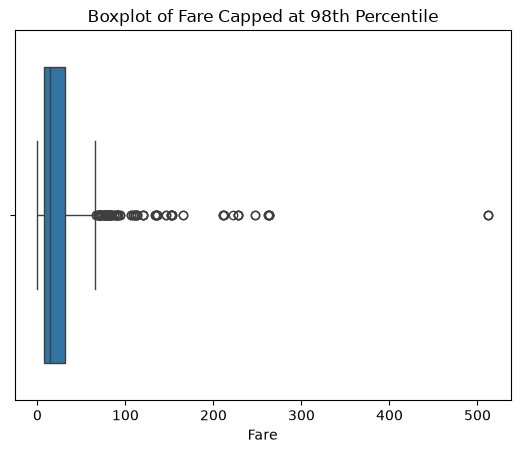

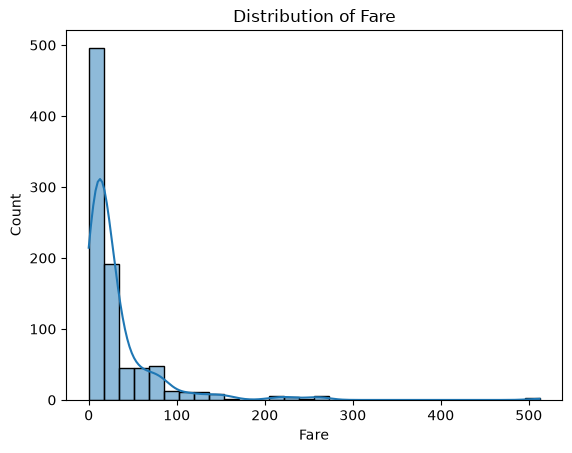

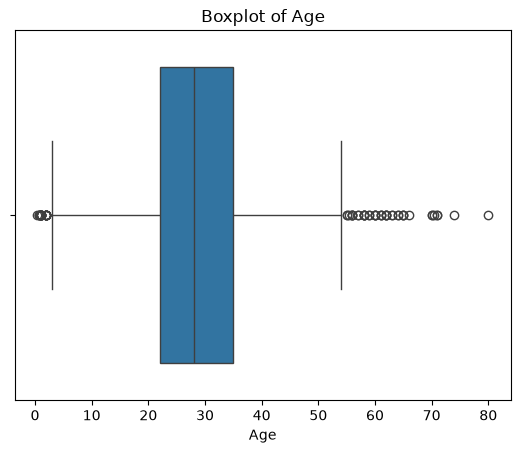

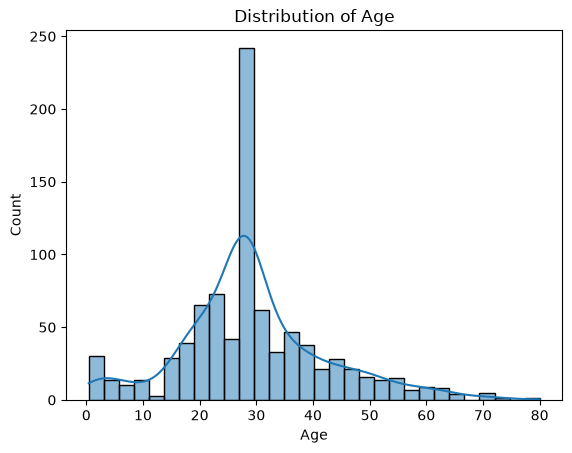

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



sns.boxplot(x=titanic_data["Fare"])
plt.title("Boxplot of Fare Capped at 98th Percentile")
plt.show()

# Histogram for Fare
sns.histplot(titanic_data["Fare"], bins=30, kde=True)
plt.title("Distribution of Fare")
plt.show()

# Boxplot for Age
sns.boxplot(x=titanic_data["Age"])
plt.title("Boxplot of Age")
plt.show()

# Histogram for Age
sns.histplot(titanic_data["Age"], bins=30, kde=True)
plt.title("Distribution of Age")
plt.show()

In [18]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower_bound) | 
        (data[column] > upper_bound)
    ]
    
    print(f"{column} lower bound:", lower_bound)
    print(f"{column} upper bound:", upper_bound)
    print(f"Number of outliers in {column}:", len(outliers))
    
    return lower_bound, upper_bound, outliers

In [19]:
# Explore different quantile thresholds
quantiles_to_check = [0.95, 0.98, 0.99, 1.00]

print("Fare quantiles:")
print(titanic_data["Fare"].quantile(quantiles_to_check))

print("\nAge quantiles:")
print(titanic_data["Age"].quantile(quantiles_to_check))

Fare quantiles:
0.95    112.07915
0.98    211.33750
0.99    249.00622
1.00    512.32920
Name: Fare, dtype: float64

Age quantiles:
0.95    54.0
0.98    62.0
0.99    65.0
1.00    80.0
Name: Age, dtype: float64


In [20]:
for q in [0.95, 0.98, 0.99]:
    fare_cap = titanic_data["Fare"].quantile(q)
    age_cap = titanic_data["Age"].quantile(q)

    fare_count = (titanic_data["Fare"] > fare_cap).sum()
    age_count = (titanic_data["Age"] > age_cap).sum()

    print(f"\nQuantile: {q}")
    print(f"Fare cap: {fare_cap:.2f} | Values above cap: {fare_count}")
    print(f"Age cap: {age_cap:.2f} | Values above cap: {age_count}")


Quantile: 0.95
Fare cap: 112.08 | Values above cap: 45
Age cap: 54.00 | Values above cap: 42

Quantile: 0.98
Fare cap: 211.34 | Values above cap: 17
Age cap: 62.00 | Values above cap: 15

Quantile: 0.99
Fare cap: 249.01 | Values above cap: 9
Age cap: 65.00 | Values above cap: 8


I checked several quantile thresholds, such as 0.95, 0.98, and 0.99, using df.quantile(). I chose the 0.98 quantile because it reduced the effect of extreme values while keeping all rows in the dataset. The Fare column had more extreme outliers than Age, so capping was useful especially for Fare. Small differences between the 0.98 and 0.99 quantiles are normal because extreme values are rare and can be far apart.

In [21]:
fare_lower, fare_upper, fare_outliers = detect_outliers_iqr(titanic_data, "Fare")
age_lower, age_upper, age_outliers = detect_outliers_iqr(titanic_data, "Age")

Fare lower bound: -26.724
Fare upper bound: 65.6344
Number of outliers in Fare: 116
Age lower bound: 2.5
Age upper bound: 54.5
Number of outliers in Age: 66


In [22]:
titanic_data_capped = titanic_data.copy()

fare_cap = titanic_data_capped["Fare"].quantile(0.98)
age_cap = titanic_data_capped["Age"].quantile(0.98)

titanic_data_capped["Fare"] = titanic_data_capped["Fare"].clip(upper=fare_cap)
titanic_data_capped["Age"] = titanic_data_capped["Age"].clip(upper=age_cap)

In [23]:
print("Fare cap:", fare_cap)
print("New max Fare:", titanic_data_capped["Fare"].max())

print("Age cap:", age_cap)
print("New max Age:", titanic_data_capped["Age"].max())

Fare cap: 211.3375
New max Fare: 211.3375
Age cap: 62.0
New max Age: 62.0


In [24]:
print("Original Fare max:", titanic_data["Fare"].max())
print("Capped Fare max:", titanic_data_capped["Fare"].max())

print("Original Age max:", titanic_data["Age"].max())
print("Capped Age max:", titanic_data_capped["Age"].max())

Original Fare max: 512.3292
Capped Fare max: 211.3375
Original Age max: 80.0
Capped Age max: 62.0


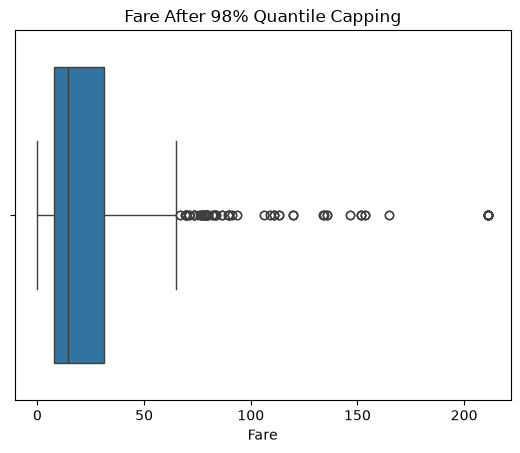

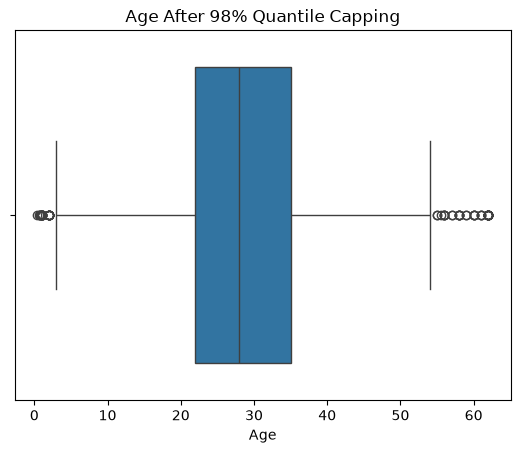

In [25]:
sns.boxplot(x=titanic_data_capped["Fare"])
plt.title("Fare After 98% Quantile Capping")
plt.show()

sns.boxplot(x=titanic_data_capped["Age"])
plt.title("Age After 98% Quantile Capping")
plt.show()

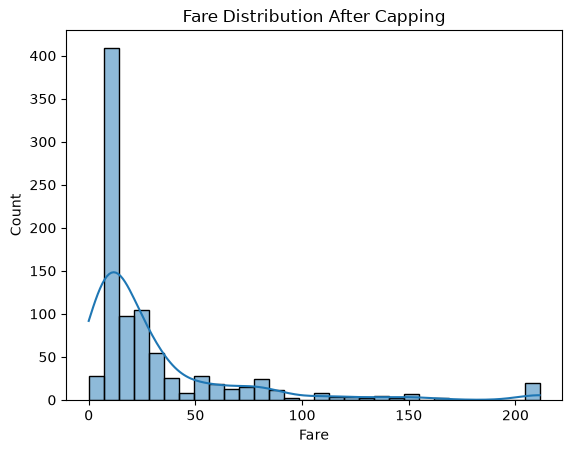

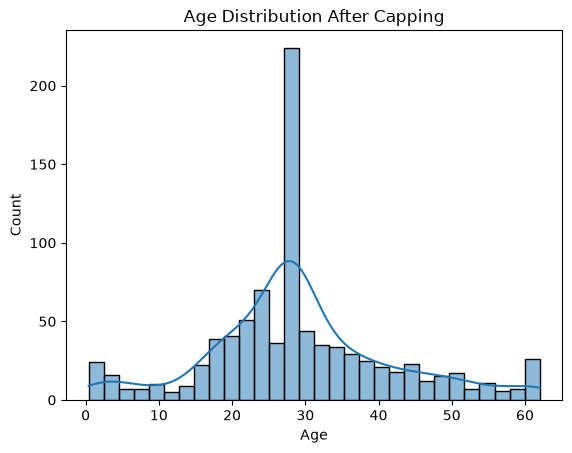

In [26]:
sns.histplot(titanic_data_capped["Fare"], bins=30, kde=True)
plt.title("Fare Distribution After Capping")
plt.show()

sns.histplot(titanic_data_capped["Age"], bins=30, kde=True)
plt.title("Age Distribution After Capping")
plt.show()

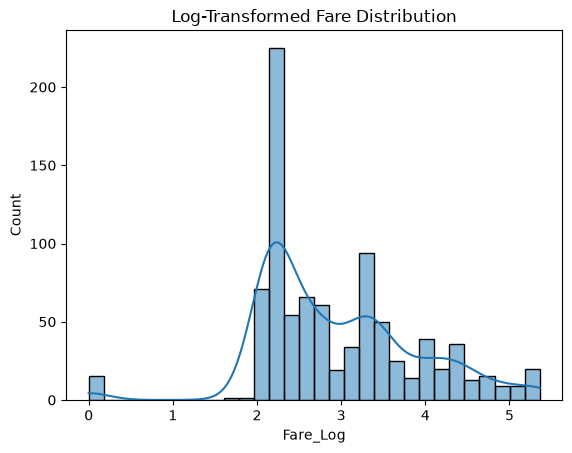

In [27]:
titanic_data_capped["Fare_Log"] = np.log1p(titanic_data_capped["Fare"])

sns.histplot(titanic_data_capped["Fare_Log"], bins=30, kde=True)
plt.title("Log-Transformed Fare Distribution")
plt.show()

In [28]:
titanic_data = titanic_data_capped.copy()

I used quantile capping to handle outliers in the Fare and Age columns. I capped both columns at the 98th percentile. This means that extremely high values were replaced with the 98th percentile value instead of removing rows from the dataset. This approach keeps all passengers in the dataset while reducing the influence of extreme values. After capping, I checked the new maximum values and visualized the columns again using boxplots and histograms.

🌟 Exercise 5: Data Standardization and Normalization
Goal: Scale numerical features to prepare for modeling.

Use StandardScaler (mean = 0, std = 1) for normally distributed features.
Use MinMaxScaler (range [0, 1]) for features that are skewed or bounded.
📌 Important: Perform this step after outlier treatment to avoid distortion caused by extreme values.